In [12]:
import os
import warnings
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
 accuracy_score, precision_score, recall_score, f1_score,
 confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
)
# Global Configuration
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [13]:
import pandas as pd
import urllib.request

print("STEP 1: DOWNLOADING SPAM DATASET FROM SOURCE")
print("=" * 45)

url_direct = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

try:
    # Download dataset
    urllib.request.urlretrieve(url_direct, "sms_data.tsv")
    print("Dataset downloaded successfully from GitHub mirror!")

    # Load dataset
    df = pd.read_csv(
        "sms_data.tsv",
        sep="\t",          # TSV files are tab-separated
        header=None,
        names=["label", "message"]
    )

except Exception as e:
    print("Primary source failed. Loading fallback dataset from sklearn...")
    print("Error:", e)

    from sklearn.datasets import fetch_20newsgroups

    ham = fetch_20newsgroups(
        subset="train",
        categories=["rec.sport.baseball"],
        shuffle=True,
        random_state=42
    )

    spam = fetch_20newsgroups(
        subset="train",
        categories=["sci.crypt"],
        shuffle=True,
        random_state=42
    )

    messages = list(ham.data[:1000]) + list(spam.data[:1000])
    labels = ["ham"] * 1000 + ["spam"] * 1000

    df = pd.DataFrame({
        "label": labels,
        "message": messages
    })

# Dataset Exploration
print(f"Dataset shape: {df.shape}")

print("\nFirst 5 messages:")
print(df.head())

print("\nClass Distribution:")
print(df["label"].value_counts())

spam_pct = df["label"].value_counts(normalize=True)["spam"] * 100
print(f"\nSpam percentage: {spam_pct:.2f}%")

STEP 1: DOWNLOADING SPAM DATASET FROM SOURCE
Dataset downloaded successfully from GitHub mirror!
Dataset shape: (5572, 2)

First 5 messages:
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam percentage: 13.41%


STEP 2: VISUALIZING SPAM VS HAM PATTERNS


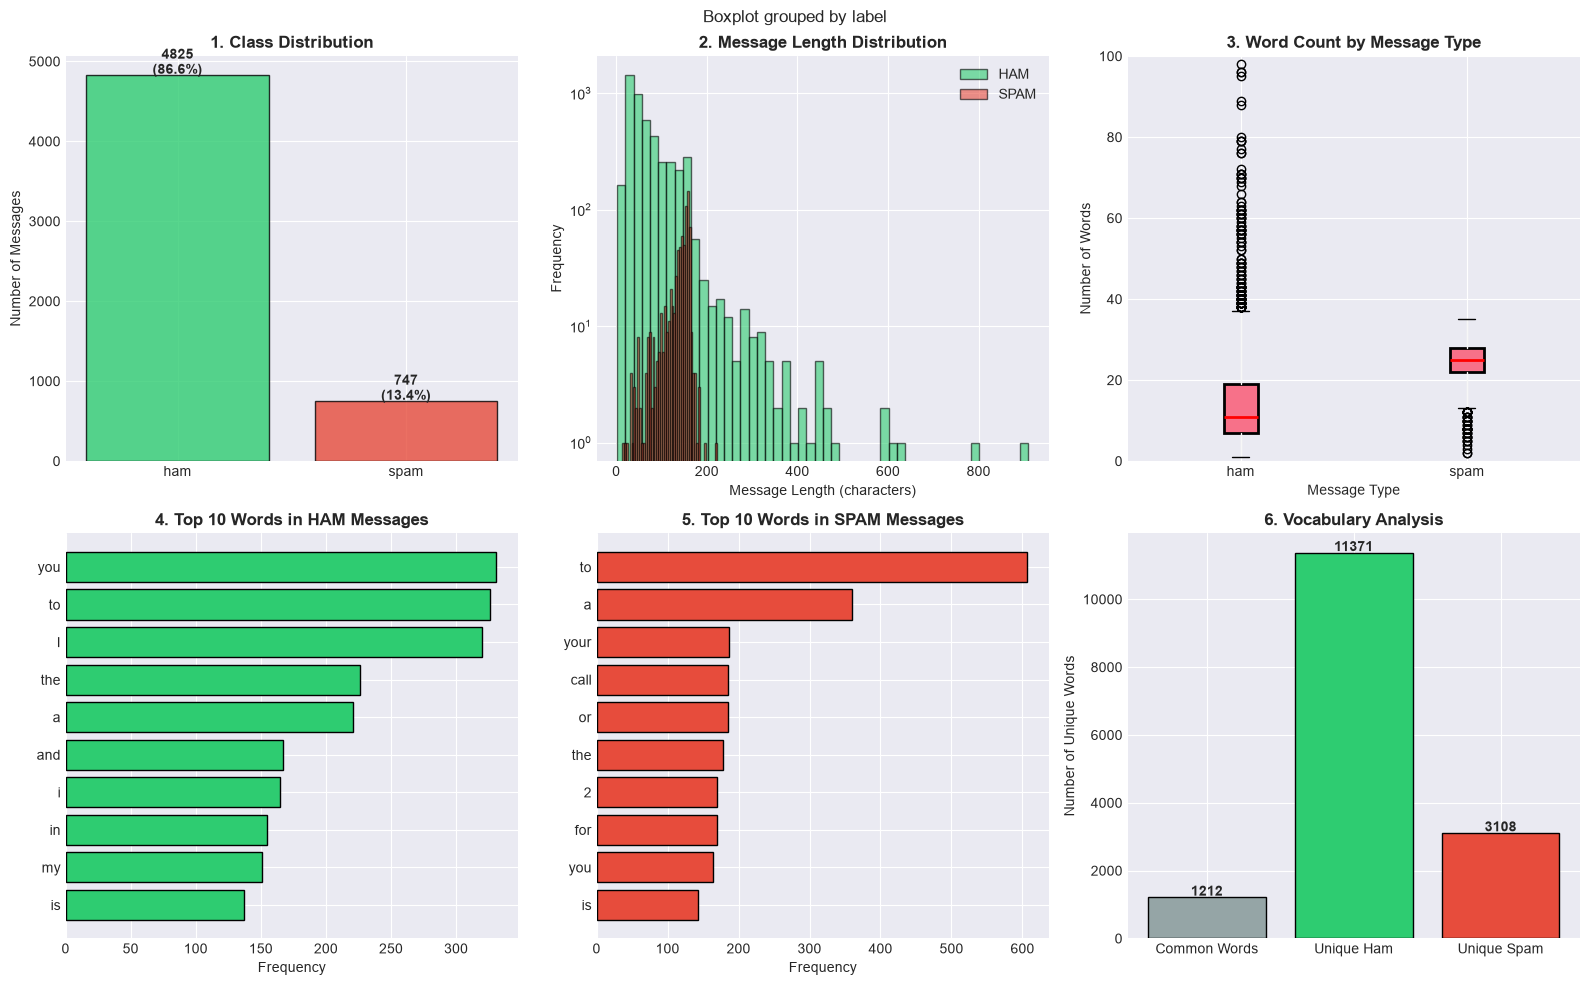

In [14]:
print("STEP 2: VISUALIZING SPAM VS HAM PATTERNS")
print("=" * 45)

from collections import Counter

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('SMS/Email Spam Classification - Data Analysis', fontsize=16, fontweight='bold')

# 1. Class distribution
ax1 = axes[0, 0]
class_counts = df['label'].value_counts()
colors_class = ['#2ecc71', '#e74c3c']

bars = ax1.bar(
    class_counts.index,
    class_counts.values,
    color=colors_class,
    edgecolor='black',
    alpha=0.8
)

ax1.set_title('1. Class Distribution', fontsize=12, fontweight='bold')
ax1.set_ylabel('Number of Messages')

for bar, count in zip(bars, class_counts.values):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 20,
        f'{count}\n({count / len(df) * 100:.1f}%)',
        ha='center',
        fontweight='bold'
    )

# 2. Message length distribution
ax2 = axes[0, 1]

df['message_length'] = df['message'].str.len()

for label, color in zip(['ham', 'spam'], ['#2ecc71', '#e74c3c']):
    subset = df[df['label'] == label]['message_length']
    ax2.hist(
        subset,
        bins=50,
        alpha=0.6,
        label=label.upper(),
        color=color,
        edgecolor='black'
    )

ax2.set_title('2. Message Length Distribution', fontsize=12, fontweight='bold')
ax2.set_xlabel('Message Length (characters)')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.set_yscale('log')

# 3. Word count distribution
ax3 = axes[0, 2]

df['word_count'] = df['message'].str.split().str.len()

df.boxplot(
    column='word_count',
    by='label',
    ax=ax3,
    patch_artist=True,
    boxprops=dict(linewidth=2),
    medianprops=dict(linewidth=2, color='red')
)

ax3.set_title('3. Word Count by Message Type', fontsize=12, fontweight='bold')
ax3.set_xlabel('Message Type')
ax3.set_ylabel('Number of Words')
ax3.set_ylim(0, 100)

# 4. Top words in HAM messages
ax4 = axes[1, 0]

ham_words = ' '.join(df[df['label'] == 'ham']['message'].head(1000)).split()
ham_top10 = Counter(ham_words).most_common(10)

words_ham, counts_ham = zip(*ham_top10)

ax4.barh(words_ham, counts_ham, color='#2ecc71', edgecolor='black')
ax4.set_title('4. Top 10 Words in HAM Messages', fontsize=12, fontweight='bold')
ax4.set_xlabel('Frequency')
ax4.invert_yaxis()

# 5. Top words in SPAM messages
ax5 = axes[1, 1]

spam_words = ' '.join(df[df['label'] == 'spam']['message'].head(1000)).split()
spam_top10 = Counter(spam_words).most_common(10)

words_spam, counts_spam = zip(*spam_top10)

ax5.barh(words_spam, counts_spam, color='#e74c3c', edgecolor='black')
ax5.set_title('5. Top 10 Words in SPAM Messages', fontsize=12, fontweight='bold')
ax5.set_xlabel('Frequency')


ax5.invert_yaxis()

# 6. Common vs Unique words
ax6 = axes[1, 2]

ham_set = set(' '.join(df[df['label'] == 'ham']['message']).split())
spam_set = set(' '.join(df[df['label'] == 'spam']['message']).split())

common_words = len(ham_set.intersection(spam_set))
unique_ham = len(ham_set - spam_set)
unique_spam = len(spam_set - ham_set)

x_labels = ['Common Words', 'Unique Ham', 'Unique Spam']
y_vals = [common_words, unique_ham, unique_spam]

ax6.bar(
    x_labels,
    y_vals,
    color=['#95a5a6', '#2ecc71', '#e74c3c'],
    edgecolor='black'
)

ax6.set_title('6. Vocabulary Analysis', fontsize=12, fontweight='bold')
ax6.set_ylabel('Number of Unique Words')

for i, (bar_name, val) in enumerate(zip(x_labels, y_vals)):
    ax6.text(
        i,
        val + 50,
        str(val),
        ha='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [15]:
print("STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING")
print("=" * 45)
# Binary encoding: 1 = Spam, 0 = Ham
y = (df['label'] == 'spam').astype(int)
X_text = df['message']
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(
 max_features=3000,
 stop_words='english',
 ngram_range=(1, 2),
 lowercase=True,
 max_df=0.8,
 min_df=2 )
X = vectorizer.fit_transform(X_text)
print(f"Feature matrix shape: {X.shape}")
print(f"Sample features: {vectorizer.get_feature_names_out()[:15]}")
# Stratified Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
 X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"Baseline accuracy: {max(y.value_counts(normalize=True)) * 100:.2f}%")

STEP 3: TEXT PREPROCESSING & FEATURE ENGINEERING
Feature matrix shape: (5572, 3000)
Sample features: ['00' '00 sub' '000' '000 bonus' '000 cash' '02' '03' '03 2nd' '04' '05'
 '06' '06 03' '0800' '0800 542' '08000839402']
Training set: 4457 samples
Test set: 1115 samples
Baseline accuracy: 86.59%


In [16]:
print("STEP 4: TRAINING NAIVE BAYES CLASSIFIER")
print("=" * 45)
model = MultinomialNB(alpha=0.5)
model.fit(X_train, y_train)
print("Model trained successfully!")
print(f"Smoothing Parameter (alpha): {model.alpha}")

STEP 4: TRAINING NAIVE BAYES CLASSIFIER
Model trained successfully!
Smoothing Parameter (alpha): 0.5


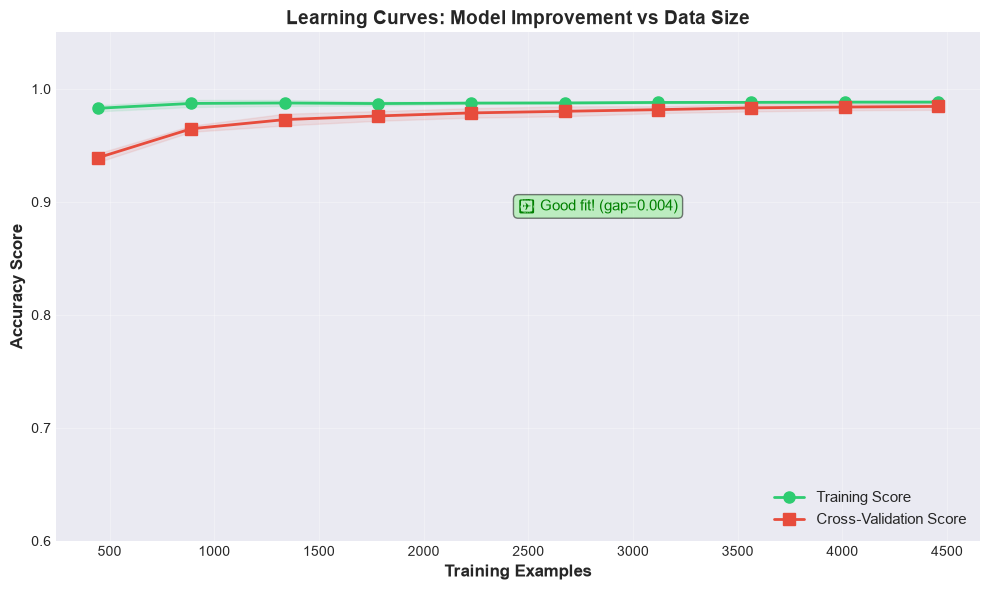

In [17]:
print("=" * 45)

train_sizes, train_scores, test_scores = learning_curve(
    model,
    X,
    y,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.1,
    color='#2ecc71'
)

ax.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.1,
    color='#e74c3c'
)

ax.plot(
    train_sizes,
    train_mean,
    'o-',
    label='Training Score',
    color='#2ecc71',
    linewidth=2,
    markersize=8
)

ax.plot(
    train_sizes,
    test_mean,
    's-',
    label='Cross-Validation Score',
    color='#e74c3c',
    linewidth=2,
    markersize=8
)

ax.set_xlabel('Training Examples', fontsize=12, fontweight='bold')
ax.set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
ax.set_title(
    'Learning Curves: Model Improvement vs Data Size',
    fontsize=14,
    fontweight='bold'
)

ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim([0.6, 1.05])

gap = train_mean[-1] - test_mean[-1]

if gap > 0.1:
    ax.text(
        0.5,
        0.65,
        f' Overfitting detected (gap={gap:.3f})',
        transform=ax.transAxes,
        fontsize=11,
        color='red',
        bbox=dict(
            boxstyle="round",
            facecolor='yellow',
            alpha=0.5
        )
    )
else:
    ax.text(
        0.5,
        0.65,
        f'✓ Good fit! (gap={gap:.3f})',
        transform=ax.transAxes,
        fontsize=11,
        color='green',
        bbox=dict(
            boxstyle="round",
            facecolor='lightgreen',
            alpha=0.5
        )
    )

plt.tight_layout()
plt.show()


In [19]:
# How well does the trained model classify new, unseen messages
print("STEP 6: MODEL EVALUATION")
print("=" * 45)
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("CLASSIFICATION METRICS:")
print("-" * 40)
print(f"Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision * 100:.2f}%)")
print(f"Recall: {recall:.4f} ({recall * 100:.2f}%)")
print(f"F1-Score: {f1:.4f} ({f1 * 100:.2f}%)")
print("DETAILED CLASSIFICATION REPORT:")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['HAM (0)', 'SPAM (1)']))

STEP 6: MODEL EVALUATION
CLASSIFICATION METRICS:
----------------------------------------
Accuracy: 0.9821 (98.21%)
Precision: 0.9924 (99.24%)
Recall: 0.8725 (87.25%)
F1-Score: 0.9286 (92.86%)
DETAILED CLASSIFICATION REPORT:


              precision    recall  f1-score   support

     HAM (0)       0.98      1.00      0.99       966
    SPAM (1)       0.99      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.96      1115
weighted avg       0.98      0.98      0.98      1115



STEP 7: COMPREHENSIVE VISUAL EVALUATION


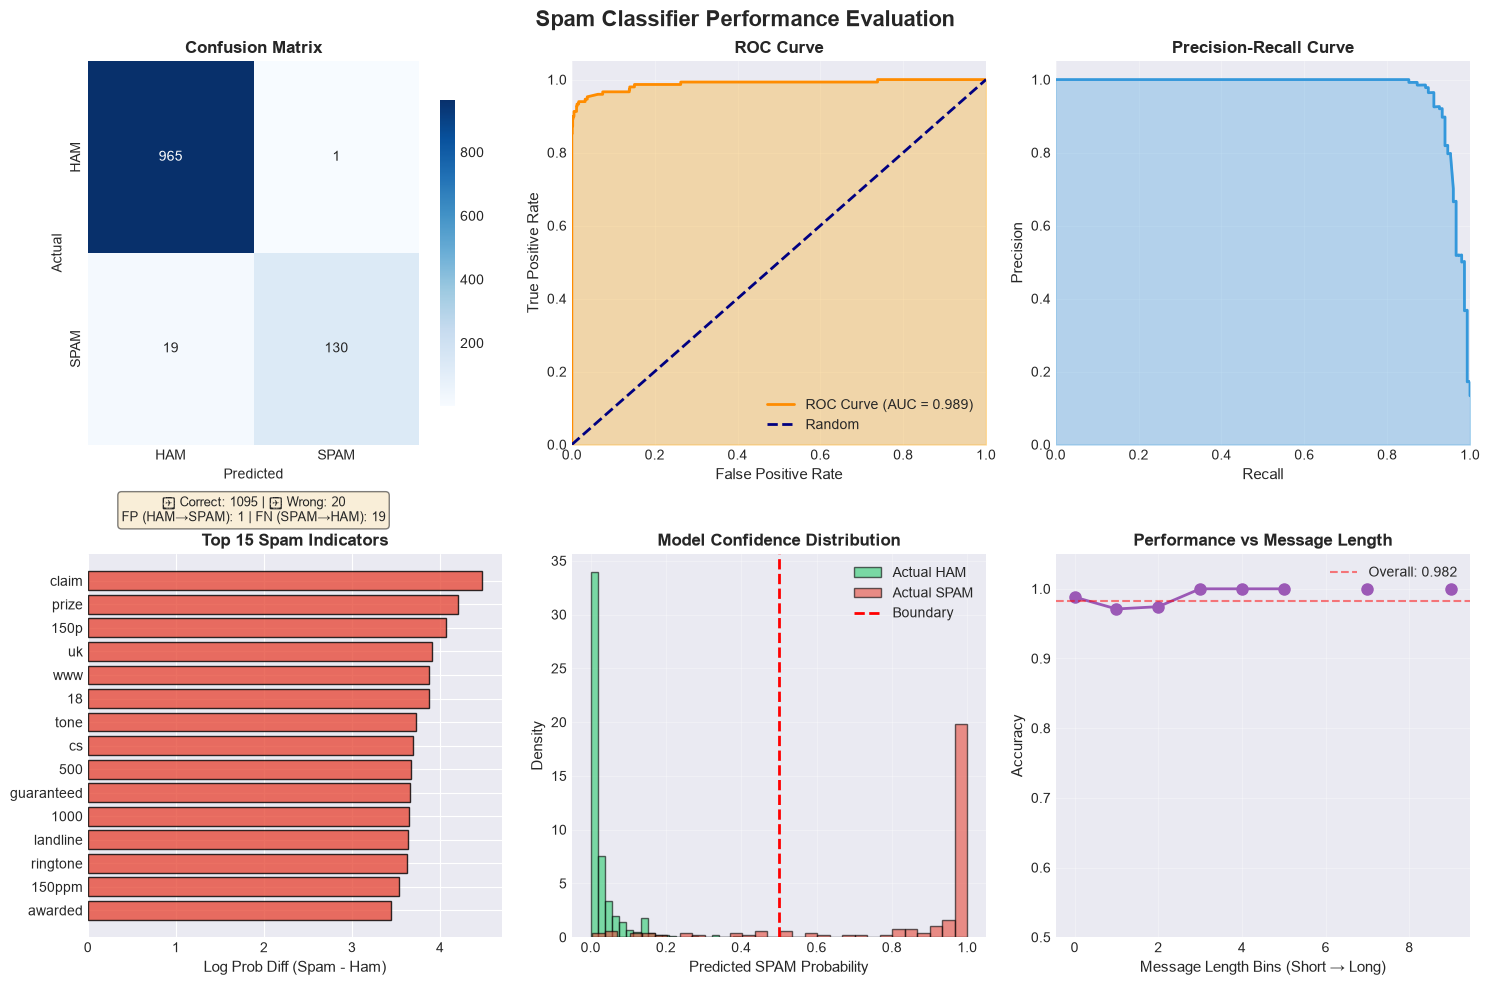

In [20]:
print("STEP 7: COMPREHENSIVE VISUAL EVALUATION")
print("=" * 45)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Spam Classifier Performance Evaluation', fontsize=16, fontweight='bold')

# 1. Confusion Matrix
ax1 = axes[0, 0]

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax1,
    xticklabels=['HAM', 'SPAM'],
    yticklabels=['HAM', 'SPAM'],
    cbar_kws={"shrink": 0.8}
)

ax1.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

tn, fp, fn, tp = cm.ravel()

ax1.text(
    0.5,
    -0.20,
    f'✓ Correct: {tn+tp} | ✗ Wrong: {fp+fn}\n'
    f'FP (HAM→SPAM): {fp} | FN (SPAM→HAM): {fn}',
    transform=ax1.transAxes,
    ha='center',
    fontsize=9,
    bbox=dict(
        boxstyle="round",
        facecolor='wheat',
        alpha=0.5
    )
)

# 2. ROC Curve
ax2 = axes[0, 1]

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

ax2.plot(
    fpr,
    tpr,
    color='darkorange',
    lw=2,
    label=f'ROC Curve (AUC = {roc_auc:.3f})'
)

ax2.plot(
    [0, 1],
    [0, 1],
    color='navy',
    lw=2,
    linestyle='--',
    label='Random'
)

ax2.fill_between(
    fpr,
    tpr,
    alpha=0.3,
    color='orange'
)

ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate', fontsize=11)
ax2.set_ylabel('True Positive Rate', fontsize=11)
ax2.set_title('ROC Curve', fontsize=12, fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = axes[0, 2]

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba
)

ax3.plot(
    recall_curve,
    precision_curve,
    color='#3498db',
    lw=2
)

ax3.fill_between(
    recall_curve,
    precision_curve,
    alpha=0.3,
    color='#3498db'
)

ax3.set_xlabel('Recall', fontsize=11)
ax3.set_ylabel('Precision', fontsize=11)
ax3.set_title('Precision-Recall Curve', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])

# 4. Top Predictive Features
ax4 = axes[1, 0]

feature_names = vectorizer.get_feature_names_out()

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': model.feature_log_prob_[1] - model.feature_log_prob_[0]
}).sort_values(
    'importance',
    ascending=False
).head(15)

ax4.barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color='#e74c3c',
    edgecolor='black',
    alpha=0.8
)

ax4.set_xlabel('Log Prob Diff (Spam - Ham)', fontsize=11)
ax4.set_title('Top 15 Spam Indicators', fontsize=12, fontweight='bold')
ax4.invert_yaxis()

# 5. Prediction Confidence Distribution
ax5 = axes[1, 1]

spam_proba = y_pred_proba[y_test == 1]
ham_proba = y_pred_proba[y_test == 0]

ax5.hist(
    ham_proba,
    bins=30,
    alpha=0.6,
    label='Actual HAM',
    color='#2ecc71',
    edgecolor='black',
    density=True
)

ax5.hist(
    spam_proba,
    bins=30,
    alpha=0.6,
    label='Actual SPAM',
    color='#e74c3c',
    edgecolor='black',
    density=True
)

ax5.axvline(
    x=0.5,
    color='red',
    linestyle='--',
    linewidth=2,
    label='Boundary'
)

ax5.set_xlabel('Predicted SPAM Probability', fontsize=11)
ax5.set_ylabel('Density', fontsize=11)
ax5.set_title('Model Confidence Distribution', fontsize=12, fontweight='bold')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 6. Performance by Message Length
ax6 = axes[1, 2]

test_indices = y_test.index

test_lengths = df.loc[
    test_indices,
    'message_length'
].values

df_test = pd.DataFrame({
    'true_label': y_test.values,
    'pred_label': y_pred,
    'length': test_lengths
})

df_test['length_bin'] = pd.cut(
    df_test['length'],
    bins=10
)

accuracy_by_length = df_test.groupby(
    'length_bin',
    observed=False
).apply(
    lambda g: accuracy_score(
        g['true_label'],
        g['pred_label']
    ) if len(g) > 0 else np.nan
)

ax6.plot(
    range(len(accuracy_by_length)),
    accuracy_by_length.values,
    'o-',
    color='#9b59b6',
    linewidth=2,
    markersize=8
)

ax6.set_xlabel(
    'Message Length Bins (Short → Long)',
    fontsize=11
)

ax6.set_ylabel('Accuracy', fontsize=11)

ax6.set_title(
    'Performance vs Message Length',
    fontsize=12,
    fontweight='bold'
)

ax6.set_ylim([0.5, 1.05])

ax6.grid(True, alpha=0.3)

ax6.axhline(
    y=accuracy,
    color='red',
    linestyle='--',
    alpha=0.5,
    label=f'Overall: {accuracy:.3f}'
)

ax6.legend()

plt.tight_layout()
plt.show()

In [22]:
print("STEP 8: LIVE SPAM DETECTION DEMO")
print("=" * 45)

test_messages = [
    "Congratulations! You've won a free iPhone! Click here to claim now!",
    "Hey, are we still meeting for lunch tomorrow?",
    "URGENT: Your account has been compromised. Verify now: bit.ly/xxx",
    "The meeting has been rescheduled to 3pm. Thanks!",
    "FREE entry to win $1000 gift card! Text WIN to 12345",
    "Don't forget to submit your report by Friday."
]

for msg in test_messages:

    msg_vectorized = vectorizer.transform([msg])

    prediction = model.predict(msg_vectorized)[0]

    probability = model.predict_proba(msg_vectorized)[0][1]

    label_str = "SPAM" if prediction == 1 else "HAM"

    confidence = probability if prediction == 1 else (1 - probability)

    print(f"\nMessage: {msg}")
    print(f"Result: {label_str} (Confidence: {confidence:.2%})")


# Cleanup workspace
if os.path.exists("sms_data.tsv"):
    os.remove("sms_data.tsv")

print("\n[INFO] Cleaned up temporary storage files.")

STEP 8: LIVE SPAM DETECTION DEMO

Message: Congratulations! You've won a free iPhone! Click here to claim now!
Result: SPAM (Confidence: 91.93%)

Message: Hey, are we still meeting for lunch tomorrow?
Result: HAM (Confidence: 99.82%)

Message: URGENT: Your account has been compromised. Verify now: bit.ly/xxx
Result: HAM (Confidence: 83.12%)

Message: The meeting has been rescheduled to 3pm. Thanks!
Result: HAM (Confidence: 98.71%)

Message: FREE entry to win $1000 gift card! Text WIN to 12345
Result: SPAM (Confidence: 97.01%)

Message: Don't forget to submit your report by Friday.
Result: HAM (Confidence: 98.03%)

[INFO] Cleaned up temporary storage files.


# Qiyas Learning Path

A collection of my machine learning and data science learning projects.

## Projects

### 07 - Spam Detection

A machine learning project that classifies SMS messages as spam or ham.

Techniques:

- TF-IDF Vectorization
- Multinomial Naive Bayes
- Model Evaluation
- ROC Curve Analysis

## Requirements

Python 3.11
pandas
scikit-learn
matplotlib
seaborn
